In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass
from typing import List, Set, Tuple, Dict
from enum import Enum
import random

In [3]:
# ============================================================================
# Constants and Data Classes
# ============================================================================

AREA_MIN = 2000.0
AREA_MAX = 7000.0
LINK_LENGTH = 1000.0
EPS = 1e-6

@dataclass
class Coord:
    x: float
    y: float

@dataclass
class Node:
    id: str
    coord: Coord

@dataclass
class Link:
    id: str
    from_node: Node
    to_node: Node
    allowed_modes: Set[str]
    
    def midpoint(self) -> Coord:
        return Coord(
            (self.from_node.coord.x + self.to_node.coord.x) / 2.0,
            (self.from_node.coord.y + self.to_node.coord.y) / 2.0
        )

class RectangleEdge(Enum):
    TOP = "top"
    BOTTOM = "bottom"
    LEFT = "left"
    RIGHT = "right"

class Network:
    def __init__(self):
        self.nodes: Dict[str, Node] = {}
        self.links: Dict[str, Link] = {}

In [4]:
# ============================================================================
# Create 9x9 Chessboard Network
# ============================================================================

def create_chessboard_network(grid_size: int = 9, link_length: float = 1000.0, 
                               start_offset: float = 1000.0) -> Network:
    """
    Create a 9x9 chessboard network similar to the MATSim example.
    
    The network has nodes at grid intersections and bidirectional links 
    connecting adjacent nodes (horizontal and vertical).
    
    Parameters:
    -----------
    grid_size : int
        Number of nodes in each dimension (default 9 for 9x9 grid)
    link_length : float
        Distance between adjacent nodes (default 1000.0)
    start_offset : float
        Offset from origin for the first node (default 1000.0)
    
    Returns:
    --------
    Network object with nodes and links
    """
    network = Network()
    
    # Create nodes
    for i in range(grid_size):
        for j in range(grid_size):
            node_id = f"({i+1},{j+1})"
            x = start_offset + i * link_length
            y = start_offset + j * link_length
            network.nodes[node_id] = Node(node_id, Coord(x, y))
    
    # Create links (horizontal and vertical, bidirectional)
    for i in range(grid_size):
        for j in range(grid_size):
            # Horizontal links (going right)
            if i < grid_size - 1:
                from_id = f"({i+1},{j+1})"
                to_id = f"({i+2},{j+1})"
                # Forward link
                link_id = f"i({i+1},{j+1})"
                network.links[link_id] = Link(
                    link_id, 
                    network.nodes[from_id], 
                    network.nodes[to_id],
                    {"car"}
                )
                # Reverse link
                link_id_r = f"i({i+2},{j+1})R"
                network.links[link_id_r] = Link(
                    link_id_r,
                    network.nodes[to_id],
                    network.nodes[from_id],
                    {"car"}
                )
            
            # Vertical links (going up)
            if j < grid_size - 1:
                from_id = f"({i+1},{j+1})"
                to_id = f"({i+1},{j+2})"
                # Forward link
                link_id = f"j({i+1},{j+1})"
                network.links[link_id] = Link(
                    link_id,
                    network.nodes[from_id],
                    network.nodes[to_id],
                    {"car"}
                )
                # Reverse link
                link_id_r = f"j({i+1},{j+2})R"
                network.links[link_id_r] = Link(
                    link_id_r,
                    network.nodes[to_id],
                    network.nodes[from_id],
                    {"car"}
                )
    
    return network

# Create the network
network = create_chessboard_network()
print(f"Created network with {len(network.nodes)} nodes and {len(network.links)} links")

Created network with 81 nodes and 288 links


In [5]:
# ============================================================================
# Helper Functions
# ============================================================================

def is_within_area(coord: Coord) -> bool:
    """Check if a coordinate is within the defined area."""
    return (coord.x + EPS >= AREA_MIN and coord.x - EPS <= AREA_MAX and
            coord.y + EPS >= AREA_MIN and coord.y - EPS <= AREA_MAX)

def get_car_links_within_area(network: Network) -> List[Link]:
    """Get all car links within the defined area, sorted by ID."""
    links = []
    for link in network.links.values():
        if "car" not in link.allowed_modes:
            continue
        if is_within_area(link.midpoint()):
            links.append(link)
    links.sort(key=lambda l: l.id)
    return links

def choose_center_link(network: Network, rng: random.Random) -> Link:
    """Choose a center link from the network."""
    center_a = network.links.get("i(5,4)")
    center_b = network.links.get("i(5,5)R")
    
    if center_a is None and center_b is None:
        raise ValueError("Center link not found: i(5,4) or i(5,5)R")
    if center_a is None:
        return center_b
    if center_b is None:
        return center_a
    return center_a if rng.random() < 0.5 else center_b

In [6]:
# ============================================================================
# Receiver Generation Functions
# ============================================================================

def generate_fully_random_receivers(network: Network, count: int, seed: int = 0) -> Set[str]:
    """
    Generate fully random receiver locations within the area.
    
    Parameters:
    -----------
    network : Network
        The network to place receivers on
    count : int
        Number of receivers to generate
    seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    Set of link IDs where receivers are placed
    """
    receiver_links = set()
    candidates = get_car_links_within_area(network)
    
    if len(candidates) < count:
        raise ValueError(f"Not enough links in area to place receivers: {len(candidates)}")
    
    rng = random.Random(13579 + seed)
    rng.shuffle(candidates)
    
    for i in range(count):
        receiver_links.add(candidates[i].id)
    
    return receiver_links


def generate_clustered_receivers(network: Network, count: int, seed: int = 0) -> Set[str]:
    """
    Generate clustered receiver locations within a randomly chosen square area.
    
    Parameters:
    -----------
    network : Network
        The network to place receivers on
    count : int
        Number of receivers to generate
    seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    Set of link IDs where receivers are placed
    """
    receiver_links = set()
    rng = random.Random(23911 + seed)
    
    square_size = 3000.0
    min_start = AREA_MIN
    max_start = AREA_MAX - square_size
    
    # Generate possible start positions
    starts = []
    v = min_start
    while v <= max_start + EPS:
        starts.append(v)
        v += LINK_LENGTH
    
    start_x = starts[rng.randint(0, len(starts) - 1)]
    start_y = starts[rng.randint(0, len(starts) - 1)]
    max_x = start_x + square_size
    max_y = start_y + square_size
    
    # Get links within the clustered square
    candidates = []
    for link in get_car_links_within_area(network):
        mid = link.midpoint()
        if (mid.x + EPS >= start_x and mid.x - EPS <= max_x and
            mid.y + EPS >= start_y and mid.y - EPS <= max_y):
            candidates.append(link)
    
    if len(candidates) < count:
        raise ValueError(f"Not enough links in clustered square to place receivers: {len(candidates)}")
    
    candidates.sort(key=lambda l: l.id)
    rng.shuffle(candidates)
    
    for i in range(count):
        receiver_links.add(candidates[i].id)
    
    return receiver_links


def add_balanced_edge_links(receiver_links: Set[str], area_links: List[Link],
                            min_x: float, max_x: float, min_y: float, max_y: float,
                            count: int, rng: random.Random) -> None:
    """
    Add links from the edges of a rectangle in a balanced manner.
    """
    edge_links = {edge: [] for edge in RectangleEdge}
    
    for link in area_links:
        mid = link.midpoint()
        if (mid.x + EPS < min_x or mid.x - EPS > max_x or
            mid.y + EPS < min_y or mid.y - EPS > max_y):
            continue
        
        if abs(mid.x - min_x) < EPS:
            edge_links[RectangleEdge.LEFT].append(link)
        elif abs(mid.x - max_x) < EPS:
            edge_links[RectangleEdge.RIGHT].append(link)
        elif abs(mid.y - min_y) < EPS:
            edge_links[RectangleEdge.BOTTOM].append(link)
        elif abs(mid.y - max_y) < EPS:
            edge_links[RectangleEdge.TOP].append(link)
    
    edges = list(RectangleEdge)
    rng.shuffle(edges)
    
    base = count // len(edges)
    remainder = count % len(edges)
    targets = {}
    for i, edge in enumerate(edges):
        targets[edge] = base + (1 if i < remainder else 0)
    
    remaining = count
    for edge in edges:
        candidates = edge_links[edge]
        candidates.sort(key=lambda l: l.id)
        rng.shuffle(candidates)
        target = targets[edge]
        
        for link in candidates:
            if link.id in receiver_links:
                continue
            receiver_links.add(link.id)
            target -= 1
            remaining -= 1
            if target == 0 or remaining == 0:
                break
        
        if remaining == 0:
            return
    
    # If still remaining, pick from all edges
    if remaining > 0:
        all_candidates = []
        for links_list in edge_links.values():
            all_candidates.extend(links_list)
        all_candidates.sort(key=lambda l: l.id)
        rng.shuffle(all_candidates)
        
        for link in all_candidates:
            if link.id in receiver_links:
                continue
            receiver_links.add(link.id)
            remaining -= 1
            if remaining == 0:
                break
    
    if remaining > 0:
        raise ValueError(f"Not enough edge links to place receivers: missing {remaining}")


def generate_hierarchy_dispersed_receivers(network: Network, count: int = 10, seed: int = 0) -> Set[str]:
    """
    Generate hierarchy dispersed receiver locations with a center and edge receivers.
    
    This creates a hierarchical pattern:
    - 1 receiver at the center
    - 3 receivers on the edges of an inner rectangle
    - 6 receivers on the edges of an outer rectangle
    
    Parameters:
    -----------
    network : Network
        The network to place receivers on
    count : int
        Number of receivers (must be 10)
    seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    Set of link IDs where receivers are placed
    """
    receiver_links = set()
    
    if count != 10:
        raise ValueError(f"Hierarchy dispersed scenario expects exactly 10 receivers, got {count}")
    
    rng = random.Random(41317 + seed)
    center_link = choose_center_link(network, rng)
    receiver_links.add(center_link.id)
    
    center = center_link.midpoint()
    area_links = get_car_links_within_area(network)
    
    # Add 3 receivers from inner rectangle edges
    add_balanced_edge_links(
        receiver_links, area_links,
        center.x - 1500.0, center.x + 1500.0,
        center.y - 1000.0, center.y + 1000.0,
        3, rng
    )
    
    # Add 6 receivers from outer rectangle edges
    add_balanced_edge_links(
        receiver_links, area_links,
        center.x - 2500.0, center.x + 2500.0,
        center.y - 2000.0, center.y + 2000.0,
        6, rng
    )
    
    return receiver_links

In [7]:
# ============================================================================
# Visualization Functions
# ============================================================================

def visualize_network_with_receivers(network: Network, receiver_links: Set[str] = None,
                                      title: str = "Chessboard Network",
                                      highlight_area: bool = True,
                                      figsize: Tuple[float, float] = (10, 10)) -> plt.Figure:
    """
    Visualize the network with optional receiver locations.
    
    Parameters:
    -----------
    network : Network
        The network to visualize
    receiver_links : Set[str]
        Set of link IDs where receivers are located (optional)
    title : str
        Title of the plot
    highlight_area : bool
        Whether to highlight the valid area
    figsize : tuple
        Figure size
    
    Returns:
    --------
    matplotlib Figure object
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw area boundary
    if highlight_area:
        rect = mpatches.Rectangle(
            (AREA_MIN, AREA_MIN), 
            AREA_MAX - AREA_MIN, 
            AREA_MAX - AREA_MIN,
            fill=True, facecolor='lightblue', alpha=0.2,
            edgecolor='blue', linewidth=2, linestyle='--',
            label='Valid Area'
        )
        ax.add_patch(rect)
    
    # Draw nodes
    for node in network.nodes.values():
        ax.plot(node.coord.x, node.coord.y, 'ko', markersize=6, zorder=3)
    
    # Draw links
    for link in network.links.values():
        mid = link.midpoint()
        from_c = link.from_node.coord
        to_c = link.to_node.coord
        
        # Check if this link has a receiver
        is_receiver = receiver_links is not None and link.id in receiver_links
        
        color = 'red' if is_receiver else 'gray'
        linewidth = 3 if is_receiver else 1
        alpha = 1.0 if is_receiver else 0.5
        
        ax.plot([from_c.x, to_c.x], [from_c.y, to_c.y], 
               color=color, linewidth=linewidth, alpha=alpha, zorder=2)
        
        if is_receiver:
            ax.plot(mid.x, mid.y, 'r*', markersize=15, zorder=4)
    
    ax.set_xlabel('X Coordinate', fontsize=12)
    ax.set_ylabel('Y Coordinate', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # Add legend
    legend_elements = [
        mpatches.Patch(facecolor='lightblue', alpha=0.3, edgecolor='blue', 
                       linestyle='--', label='Valid Area'),
        plt.Line2D([0], [0], color='gray', linewidth=1, label='Network Link'),
        plt.Line2D([0], [0], color='red', linewidth=3, label='Receiver Link'),
        plt.Line2D([0], [0], marker='*', color='red', markersize=12, 
                   linestyle='None', label='Receiver Location')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    plt.tight_layout()
    return fig


def visualize_all_distributions(network: Network, count: int = 10, seed: int = 0,
                                 figsize: Tuple[float, float] = (18, 6)) -> plt.Figure:
    """
    Visualize all three distribution types side by side.
    
    Parameters:
    -----------
    network : Network
        The network to use
    count : int
        Number of receivers to generate
    seed : int
        Random seed for reproducibility
    figsize : tuple
        Figure size
    
    Returns:
    --------
    matplotlib Figure object
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    distributions = [
        ("Fully Random", generate_fully_random_receivers(network, count, seed)),
        ("Clustered", generate_clustered_receivers(network, count, seed)),
        ("Hierarchy Dispersed", generate_hierarchy_dispersed_receivers(network, 10, seed))
    ]
    
    for ax, (dist_name, receiver_links) in zip(axes, distributions):
        # Draw area boundary
        rect = mpatches.Rectangle(
            (AREA_MIN, AREA_MIN), 
            AREA_MAX - AREA_MIN, 
            AREA_MAX - AREA_MIN,
            fill=True, facecolor='lightblue', alpha=0.2,
            edgecolor='blue', linewidth=2, linestyle='--'
        )
        ax.add_patch(rect)
        
        # Draw nodes
        for node in network.nodes.values():
            ax.plot(node.coord.x, node.coord.y, 'ko', markersize=4, zorder=3)
        
        # Draw links
        for link in network.links.values():
            mid = link.midpoint()
            from_c = link.from_node.coord
            to_c = link.to_node.coord
            
            is_receiver = link.id in receiver_links
            
            color = 'red' if is_receiver else 'gray'
            linewidth = 2.5 if is_receiver else 0.8
            alpha = 1.0 if is_receiver else 0.4
            
            ax.plot([from_c.x, to_c.x], [from_c.y, to_c.y], 
                   color=color, linewidth=linewidth, alpha=alpha, zorder=2)
            
            if is_receiver:
                ax.plot(mid.x, mid.y, 'r*', markersize=12, zorder=4)
        
        ax.set_xlabel('X Coordinate', fontsize=10)
        ax.set_ylabel('Y Coordinate', fontsize=10)
        ax.set_title(f'{dist_name}\n({len(receiver_links)} receivers)', fontsize=12, fontweight='bold')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'Receiver Distribution Comparison (seed={seed})', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


def generate_and_visualize_receivers(network: Network, 
                                      distribution: str = 'random',
                                      count: int = 10, 
                                      seed: int = 0) -> Tuple[Set[str], plt.Figure]:
    """
    Generate receivers with specified distribution and visualize.
    
    Parameters:
    -----------
    network : Network
        The network to use
    distribution : str
        Distribution type: 'random', 'clustered', or 'hierarchy'
    count : int
        Number of receivers (for 'hierarchy', must be 10)
    seed : int
        Random seed for reproducibility
    
    Returns:
    --------
    Tuple of (receiver_links set, matplotlib Figure)
    """
    if distribution == 'random':
        receiver_links = generate_fully_random_receivers(network, count, seed)
        title = f"Fully Random Distribution (n={count}, seed={seed})"
    elif distribution == 'clustered':
        receiver_links = generate_clustered_receivers(network, count, seed)
        title = f"Clustered Distribution (n={count}, seed={seed})"
    elif distribution == 'hierarchy':
        receiver_links = generate_hierarchy_dispersed_receivers(network, 10, seed)
        title = f"Hierarchy Dispersed Distribution (n=10, seed={seed})"
    else:
        raise ValueError(f"Unknown distribution type: {distribution}")
    
    fig = visualize_network_with_receivers(network, receiver_links, title)
    
    return receiver_links, fig

## Test: Visualize All Three Distributions

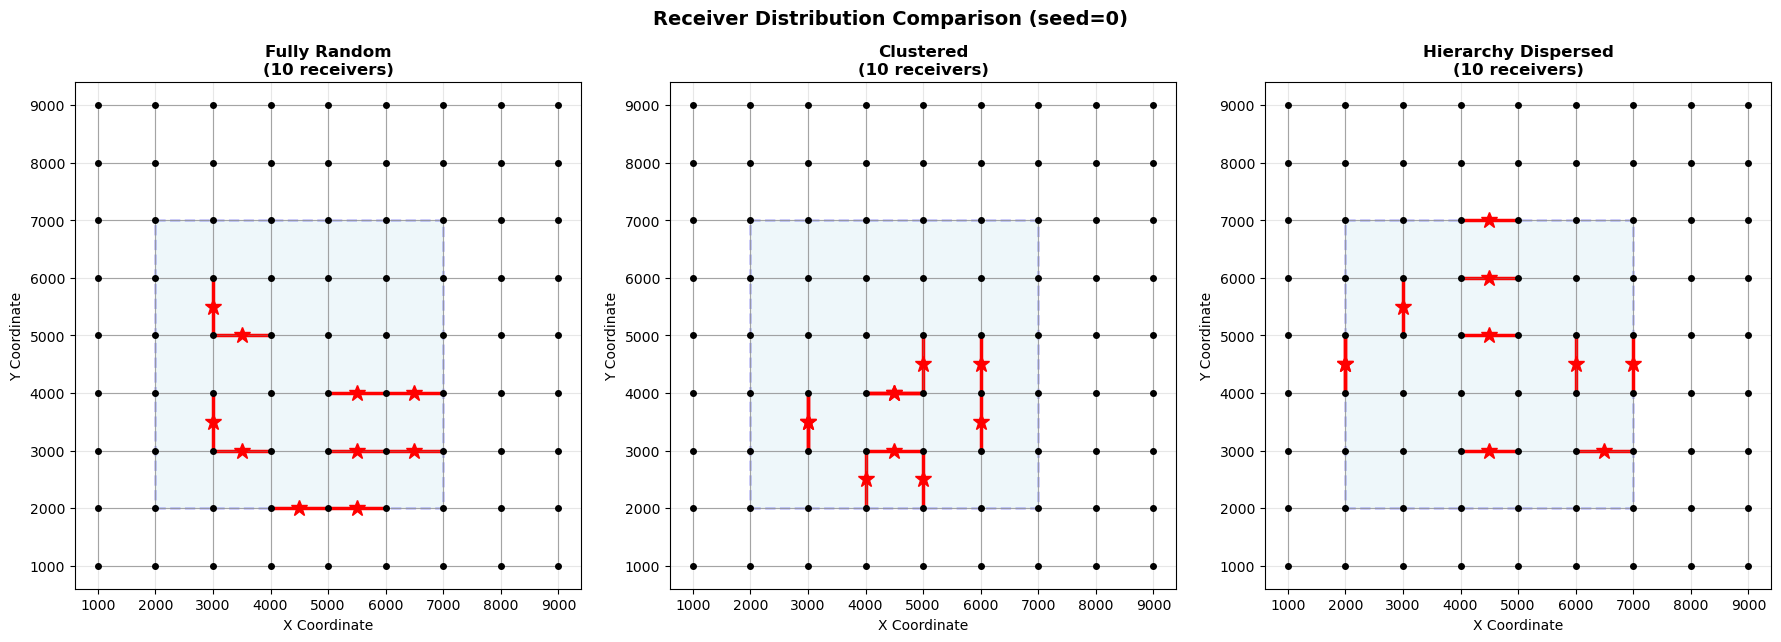

In [8]:
# Visualize all three distributions side by side
fig = visualize_all_distributions(network, count=10, seed=0)
plt.show()


=== Seed 0 ===
Random receivers: ['i(3,3)', 'i(3,5)', 'i(5,2)R', 'i(5,3)', 'i(6,2)R', 'i(6,3)', 'i(6,4)R', 'i(7,4)R', 'j(3,4)R', 'j(3,6)R']
Random receivers: ['i(3,3)', 'i(3,5)', 'i(5,2)R', 'i(5,3)', 'i(6,2)R', 'i(6,3)', 'i(6,4)R', 'i(7,4)R', 'j(3,4)R', 'j(3,6)R']
Clustered receivers: ['i(4,4)', 'i(5,3)R', 'i(5,4)R', 'j(3,3)', 'j(3,4)R', 'j(4,2)', 'j(5,3)R', 'j(5,4)', 'j(6,4)R', 'j(6,5)R']
Hierarchy receivers: ['i(4,6)', 'i(5,3)R', 'i(5,5)R', 'i(5,7)R', 'i(6,3)', 'j(2,4)', 'j(2,5)R', 'j(3,6)R', 'j(6,4)', 'j(7,5)R']

=== Seed 1 ===
Clustered receivers: ['i(4,4)', 'i(5,3)R', 'i(5,4)R', 'j(3,3)', 'j(3,4)R', 'j(4,2)', 'j(5,3)R', 'j(5,4)', 'j(6,4)R', 'j(6,5)R']
Hierarchy receivers: ['i(4,6)', 'i(5,3)R', 'i(5,5)R', 'i(5,7)R', 'i(6,3)', 'j(2,4)', 'j(2,5)R', 'j(3,6)R', 'j(6,4)', 'j(7,5)R']

=== Seed 1 ===
Random receivers: ['i(3,2)', 'i(3,3)R', 'i(3,4)', 'i(3,5)', 'i(5,2)', 'i(6,2)', 'i(6,3)', 'j(2,7)R', 'j(6,5)R', 'j(7,5)']
Random receivers: ['i(3,2)', 'i(3,3)R', 'i(3,4)', 'i(3,5)', 'i(5,2)'

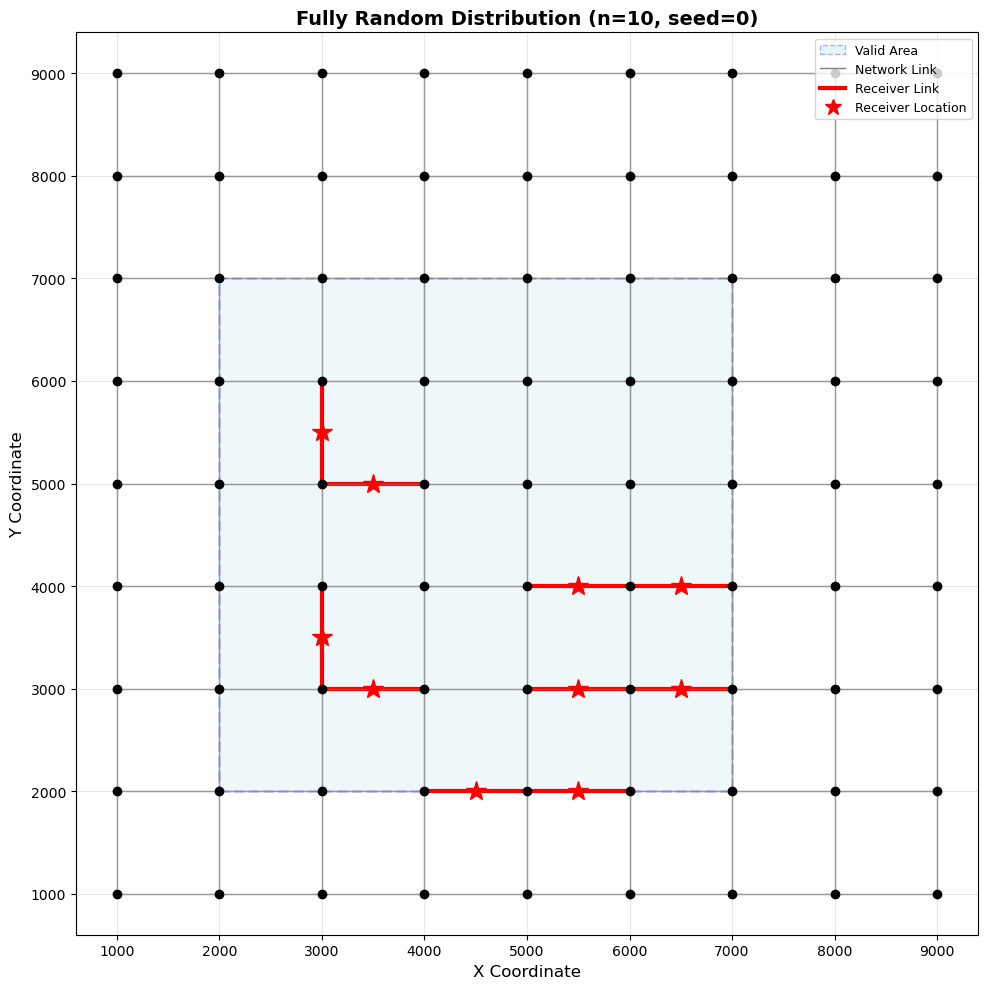

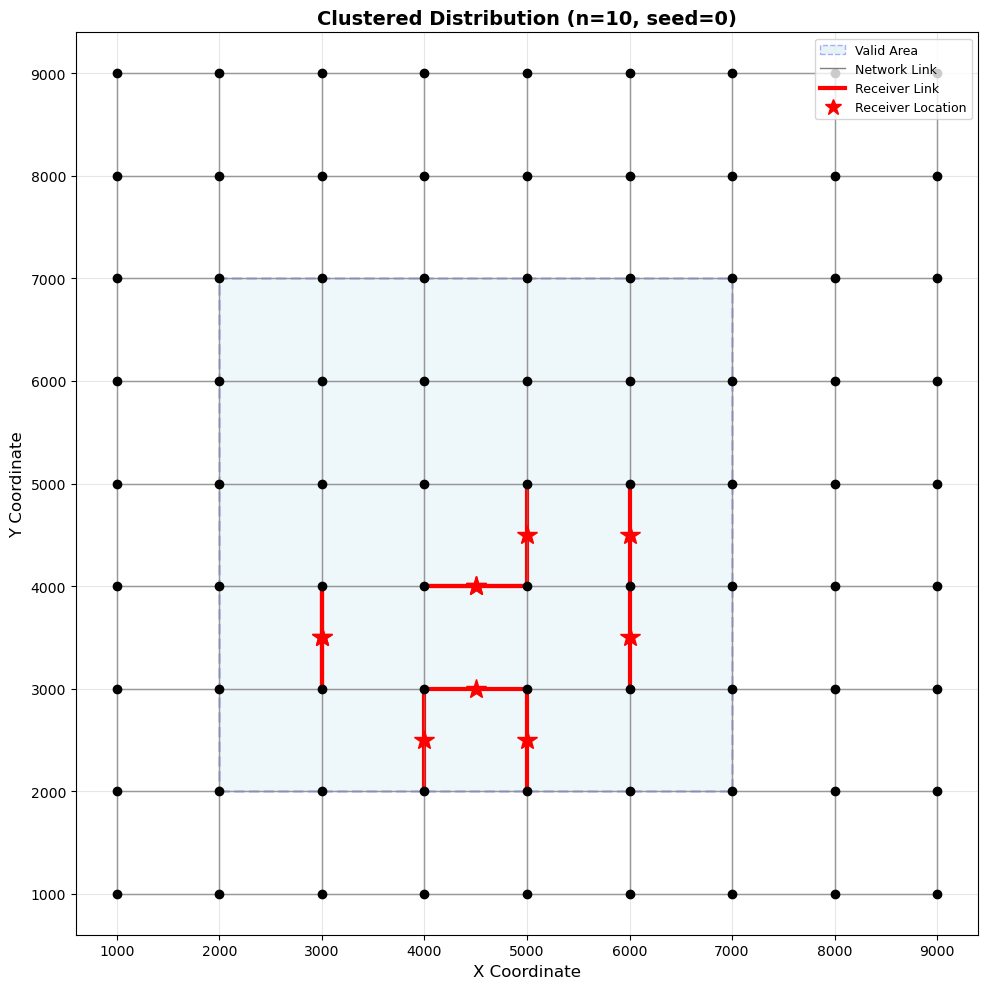

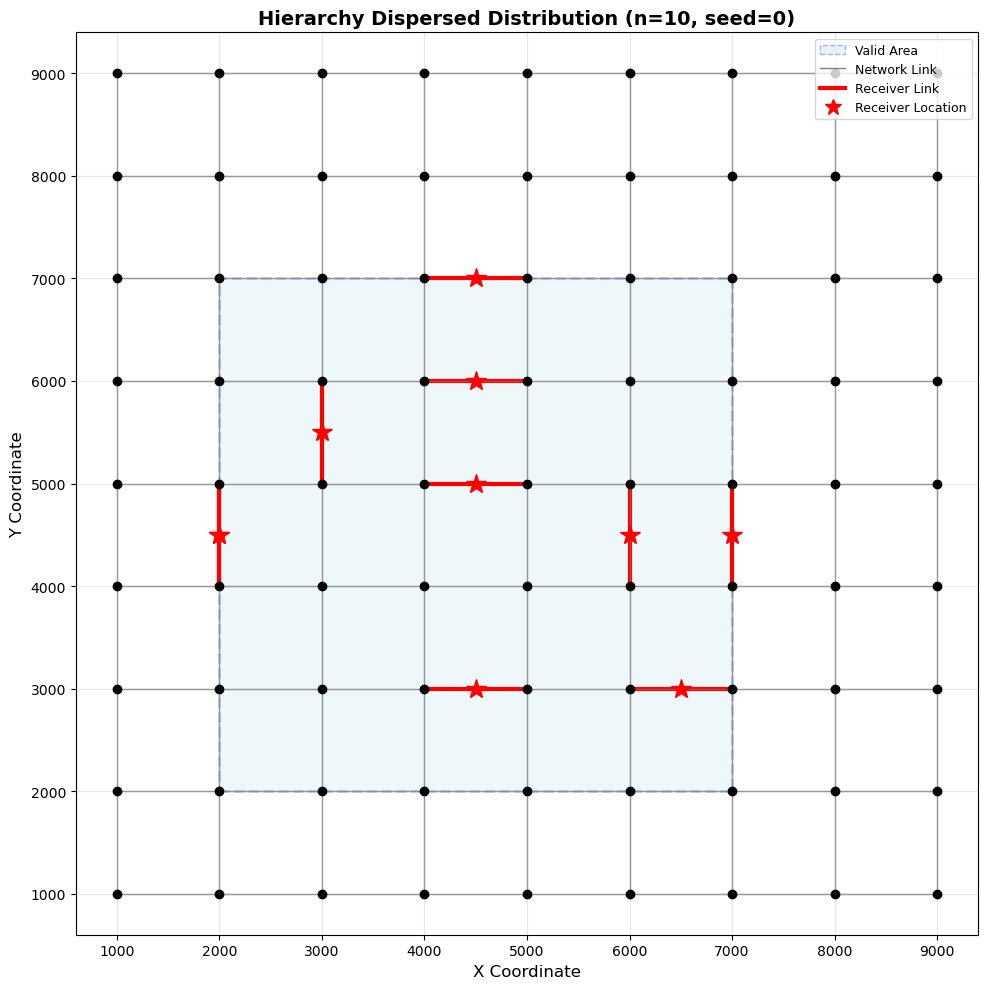

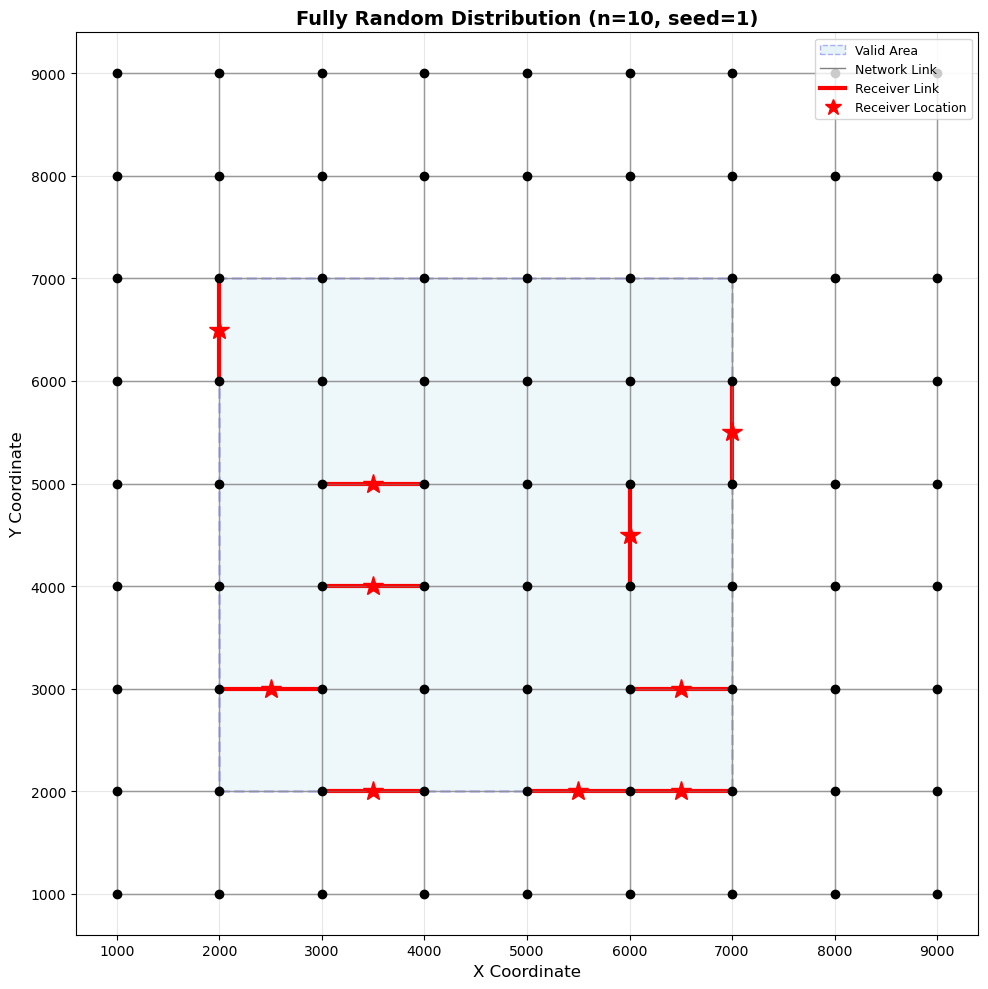

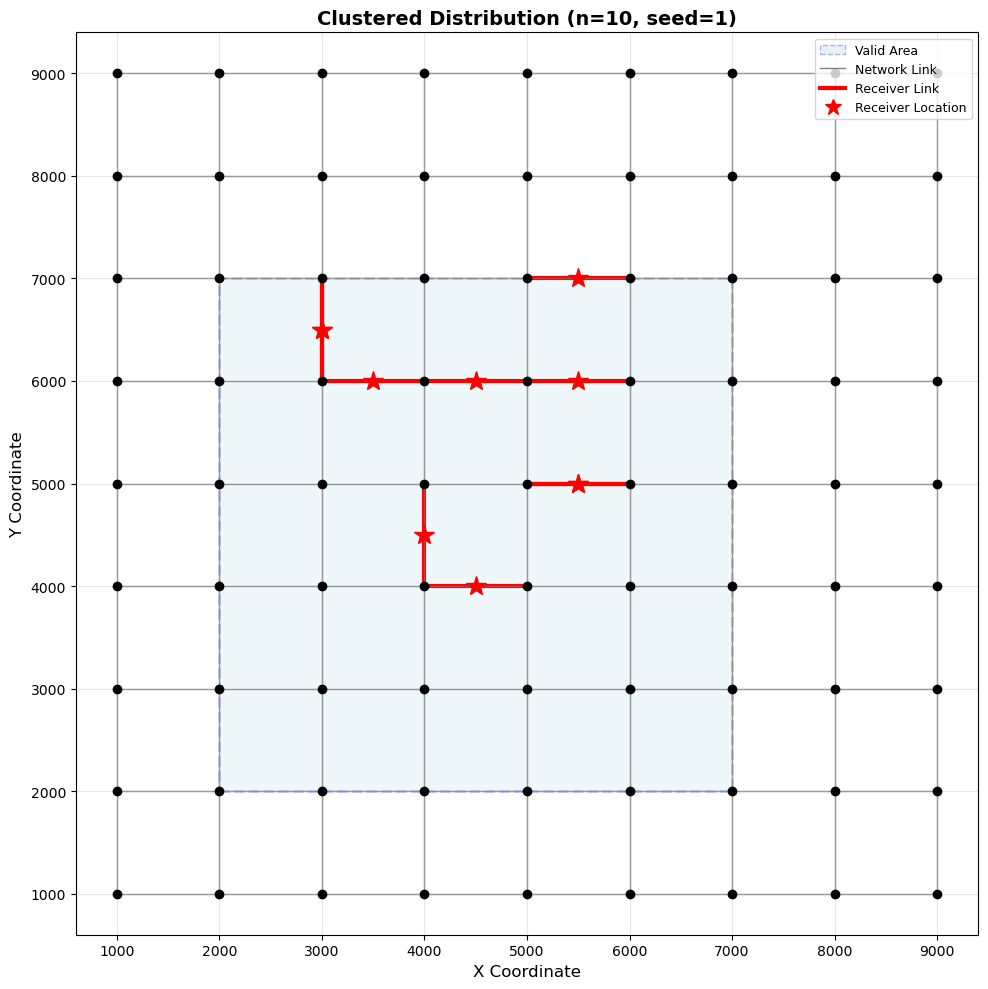

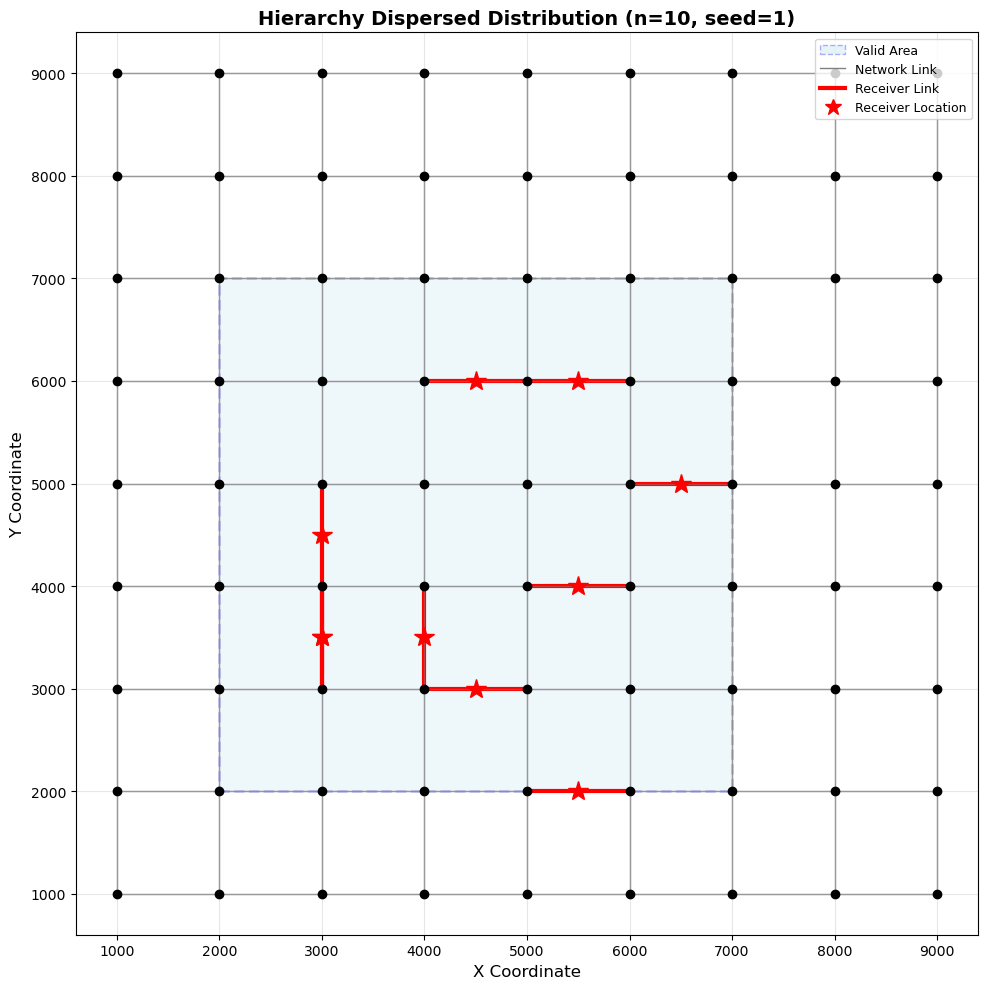

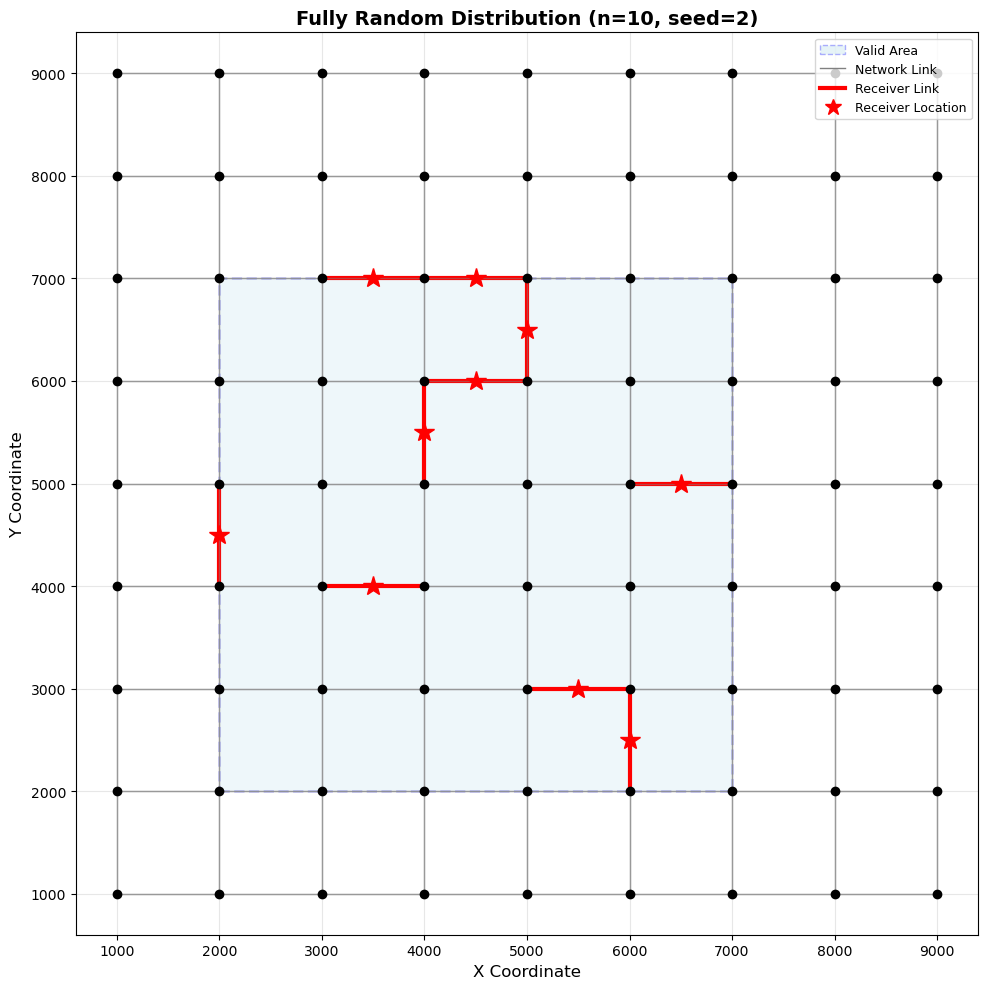

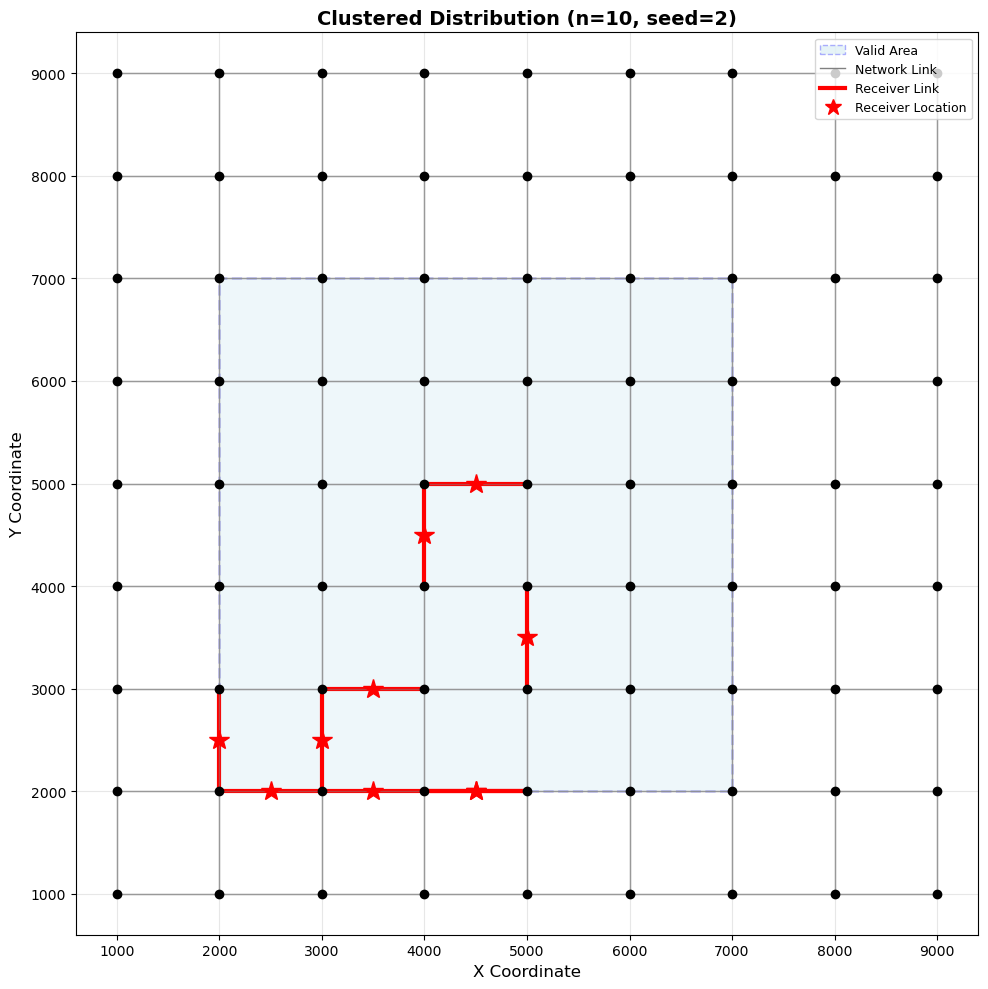

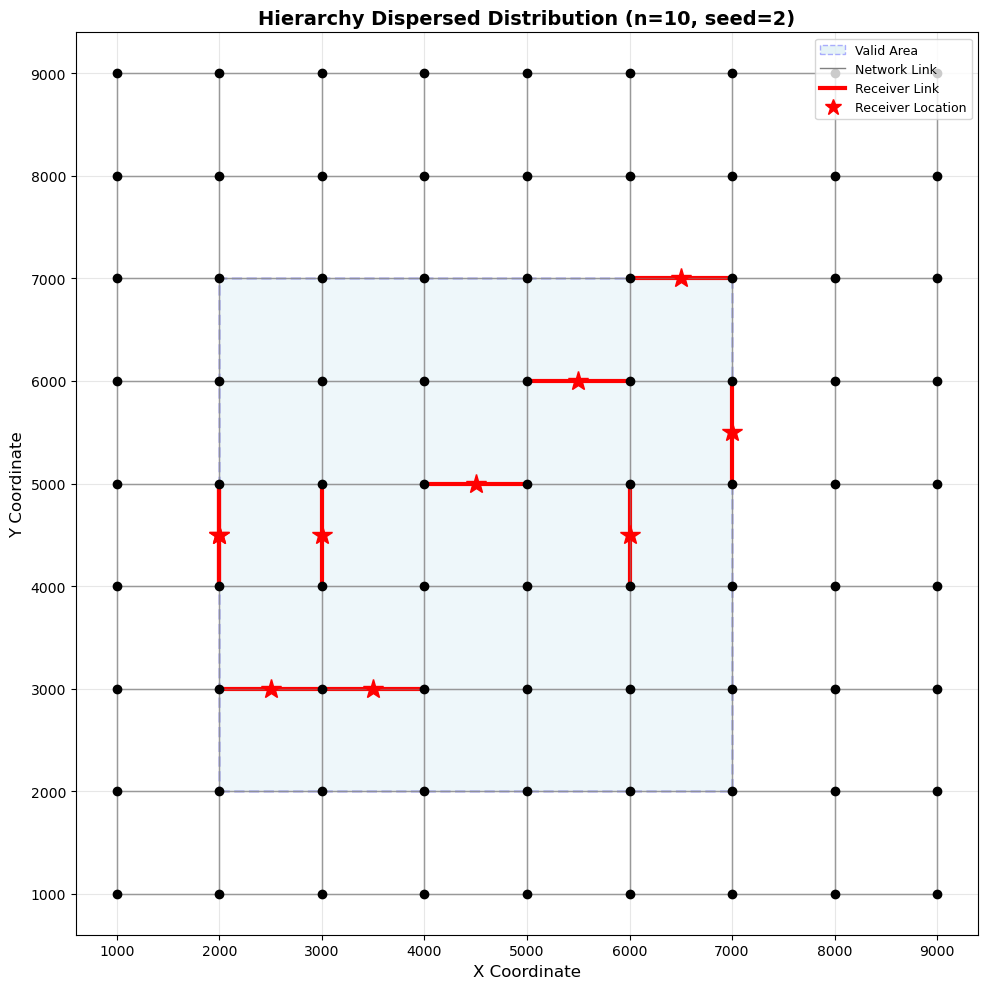

In [9]:
# Test individual distributions with different seeds
for seed in [0, 1, 2]:
    print(f"\n=== Seed {seed} ===")
    
    # Random distribution
    random_receivers, _ = generate_and_visualize_receivers(network, 'random', count=10, seed=seed)
    print(f"Random receivers: {sorted(random_receivers)}")
    
    # Clustered distribution
    clustered_receivers, _ = generate_and_visualize_receivers(network, 'clustered', count=10, seed=seed)
    print(f"Clustered receivers: {sorted(clustered_receivers)}")
    
    # Hierarchy dispersed distribution
    hierarchy_receivers, _ = generate_and_visualize_receivers(network, 'hierarchy', count=10, seed=seed)
    print(f"Hierarchy receivers: {sorted(hierarchy_receivers)}")

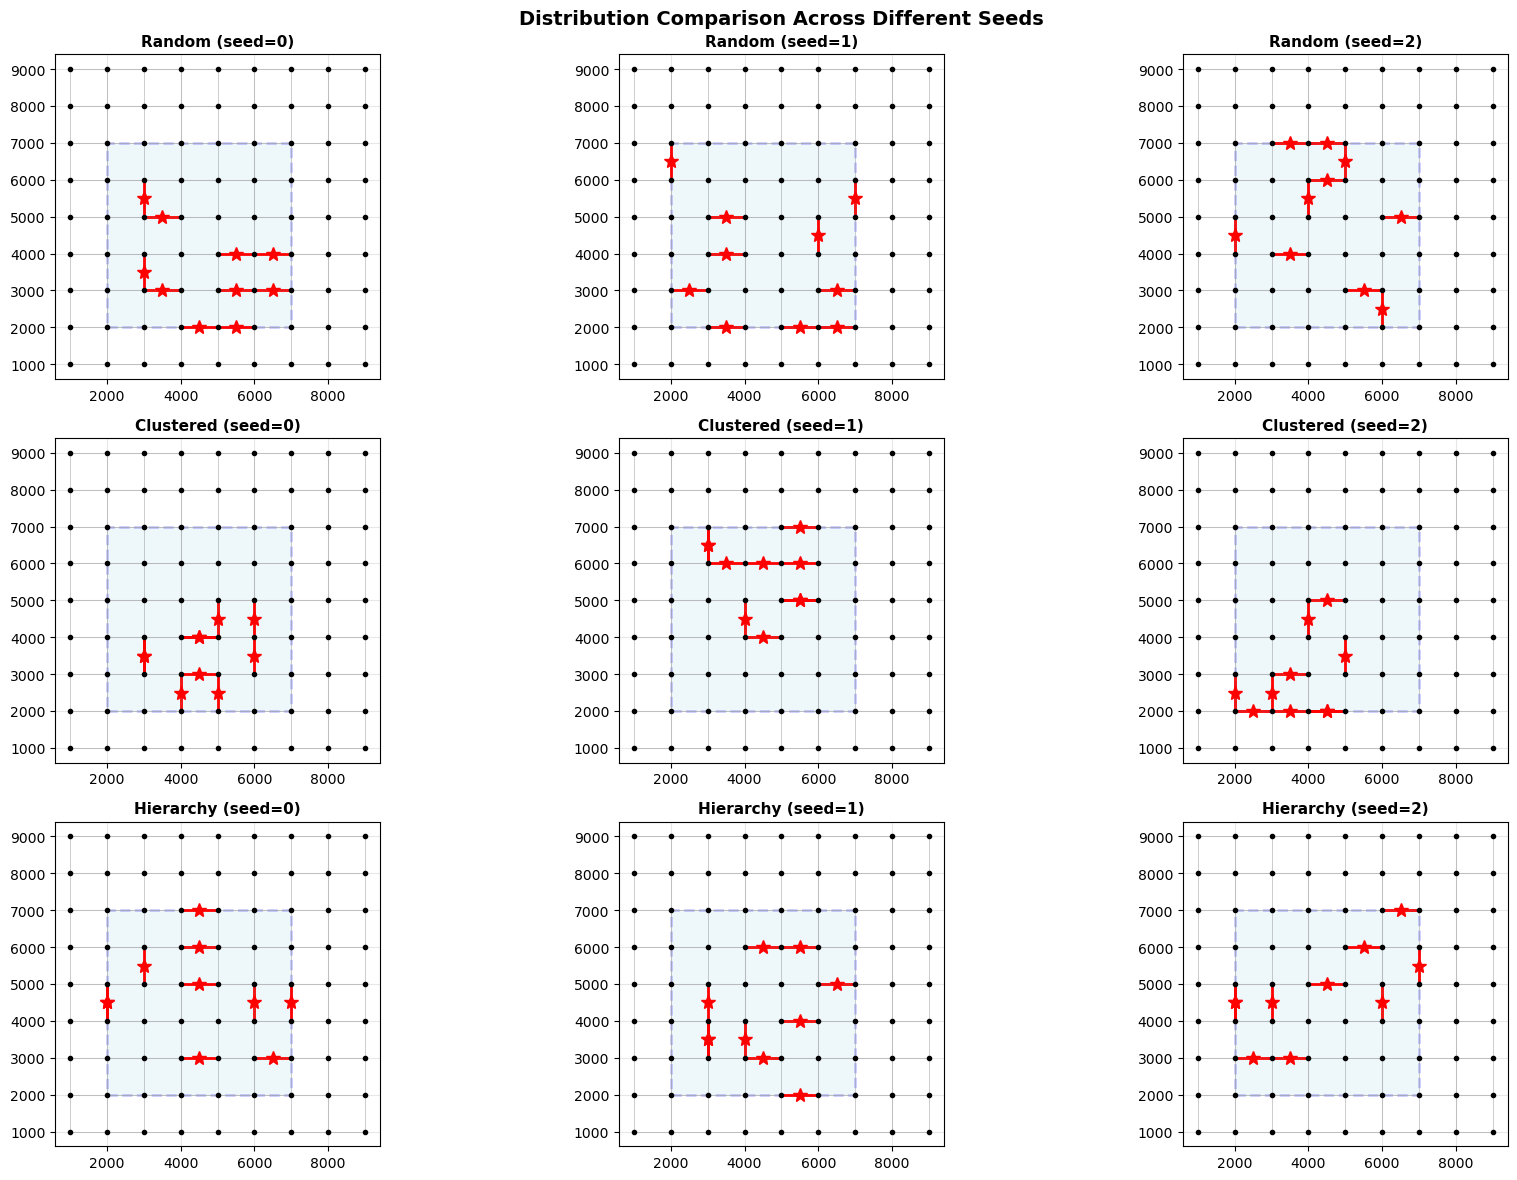

In [11]:
# Compare different seeds for the same distribution type
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row, dist_type in enumerate(['random', 'clustered', 'hierarchy']):
    for col, seed in enumerate([0, 1, 2]):
        ax = axes[row, col]
        
        if dist_type == 'random':
            receiver_links = generate_fully_random_receivers(network, 10, seed)
        elif dist_type == 'clustered':
            receiver_links = generate_clustered_receivers(network, 10, seed)
        else:
            receiver_links = generate_hierarchy_dispersed_receivers(network, 10, seed)
        
        # Draw area boundary
        rect = mpatches.Rectangle(
            (AREA_MIN, AREA_MIN), 
            AREA_MAX - AREA_MIN, 
            AREA_MAX - AREA_MIN,
            fill=True, facecolor='lightblue', alpha=0.2,
            edgecolor='blue', linewidth=2, linestyle='--'
        )
        ax.add_patch(rect)
        
        # Draw nodes
        for node in network.nodes.values():
            ax.plot(node.coord.x, node.coord.y, 'ko', markersize=3, zorder=3)
        
        # Draw links
        for link in network.links.values():
            mid = link.midpoint()
            from_c = link.from_node.coord
            to_c = link.to_node.coord
            
            is_receiver = link.id in receiver_links
            color = 'red' if is_receiver else 'gray'
            linewidth = 2 if is_receiver else 0.5
            alpha = 1.0 if is_receiver else 0.3
            
            ax.plot([from_c.x, to_c.x], [from_c.y, to_c.y], 
                   color=color, linewidth=linewidth, alpha=alpha, zorder=2)
            
            if is_receiver:
                ax.plot(mid.x, mid.y, 'r*', markersize=10, zorder=4)
        
        ax.set_title(f'{dist_type.capitalize()} (seed={seed})', fontsize=11, fontweight='bold')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

fig.suptitle('Distribution Comparison Across Different Seeds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()